# Exp-6 — Domain encoder fine-tune: `legal-swiss-roberta-large` as bi-encoder

**Why this exp.** Every retriever we have tried so far (Exp-1 → Exp-5) uses generic `BAAI/bge-m3` and ceilings around `stat_recall@500 ≈ 0.376` / `case_recall@200 ≈ 0.108`. The blocker is *not* candidate-pool size or ranking — it is the encoder. The cross-encoder rerank (Exp-4/4b) was a wash because the candidates were already the wrong ones. The court-corpus pivot (Exp-5) failed because BGE-M3 cannot bridge English-scenario → German/French/Italian legal-reasoning text without domain priors.

**The lever.** `joelniklaus/legal-swiss-roberta-large` is pre-trained on Swiss legislation + court decisions in DE/FR/IT. We turn it into a bi-encoder by:
1. **Supervision source: `rcds/swiss_citation_extraction`** — 131 K Swiss Federal court paragraphs with IOB-tagged citations in our exact `Art. N ABBR` / `BGE V P R` format. This is *clean* supervision (no train-set noise), *in-distribution* (eval is also Swiss law), and free from the train→eval split mismatch that kills any model trained on `train.csv`.
2. **Training pairs.** Anchor = paragraph text; positive = the cited statute's text from `laws_de.csv` (or BGE consideration text from `court_considerations.csv`). Pairs are mined by resolving each IOB-extracted citation string to the corpus.
3. **Hard negatives.** Top-K BGE-M3 retrieved candidates per anchor (using cached `laws_bgem3.npy` + `court_bgem3.npy`) minus the gold set. Optional reranker filter to drop false negatives (>0.5 reranker score).
4. **Loss.** `MultipleNegativesRankingLoss` (InfoNCE w/ in-batch negatives + hard-neg augmentation). 1–2 epochs.

**Eval gates (on val, same metrics as Exp-3/5).**
- `stat_recall@500` > 0.376 (beats Exp-3 ceiling) → **PROMOTE the encoder**.
- `stat_recall@200` ≥ 0.45 → strong enough for downstream rerank.
- `case_recall@200` > 0.108 (beats Exp-5) → re-encode court corpus with tuned model (deferred to Cell 12 behind a gate; only proceeds if statute side passes).

**Compute.** Training: 131 K pairs × 1024 dim × bs 32 ≈ 1–2 hr on the Blackwell 6000. Statute re-encode: 175 K × 514 tokens ≈ 10–15 min. Court re-encode: 2.47 M × 512 tokens ≈ 35–45 min (gated).

**Failure modes to watch.**
- If `legal-swiss-roberta-large` mean-pool baseline (no fine-tune) recall is *worse than* BGE-M3, the wrap-as-sentence-encoder approach is bad and we need contrastive pretraining first. Cell 7 reports this baseline before training.
- If hard-negative mining is dominated by false negatives (recall on the mining set ≥ 80 %), training collapses. Cell 8 logs the false-negative rate via reranker filter.
- If 1 epoch over 131 K already overfits (val recall plateaus), drop to 0.5 epoch + larger batch.

**Output artefacts.**
- `legal_swiss_finetuned/` — saved sentence-transformers model on Drive
- `laws_swissroberta.npy` — re-encoded statute corpus
- `court_swissroberta.npy` — re-encoded court corpus (gated)
- `query_vecs_A6.npz` — re-encoded val queries (en, de, hyde, enum)
- `exp_A6_report.json` — recall tables vs Exp-3/5 baselines + verdict

In [3]:
# --- Cell 1. Install deps (sentence-transformers train stack + datasets) ---
!pip install -qU numpy==1.26.4
!pip install -qU "sentence-transformers>=3.1.0" "transformers>=4.45.0" "accelerate>=0.34" "datasets<3.0.0" "pandas<2.2.0"
# If runtime warns about numpy downgrade, restart runtime then re-run from Cell 2.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 252.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0,

In [1]:
# --- Cell 2. Mount Drive, paths, GPU check ---
from google.colab import drive
drive.mount('/content/drive')

import json, pickle, re, time, gc, random
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import torch

ROOT = Path('/content/drive/MyDrive/swiss_law/data')
ART  = ROOT / 'artifacts'
A6   = ART / 'A6'
A6.mkdir(parents=True, exist_ok=True)

for f in ['laws_de.csv', 'val.csv']:
    assert (ROOT / f).exists(), f'missing {f} on Drive'
for f in ['laws_bgem3.npy', 'query_vecs_A3.npz', 'court_bgem3.npy', 'court_citations.json']:
    assert (ART / f).exists(), f'missing {f} — run prior exps first'

assert torch.cuda.is_available(), 'need GPU'
print('GPU:', torch.cuda.get_device_name(0))
print('Free VRAM (GB):', round(torch.cuda.mem_get_info()[0] / 1e9, 1))
random.seed(0); np.random.seed(0); torch.manual_seed(0)

Mounted at /content/drive
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Free VRAM (GB): 101.4


In [2]:
# --- Cell 3. Download rcds/swiss_citation_extraction (anonymous HF, no auth) ---
from datasets import load_dataset

# This dataset has IOB-tagged Swiss court paragraphs with LAW + CIT(=BGE) citations
# Schema check: features include `tokens`, `label_id`/`label`, sometimes `text`/`paragraph_text`
# We pull all splits (train/validation/test) and merge — we are using it as a supervised pair miner,
# not for held-out eval (val.csv stays our held-out set).
ds = load_dataset('rcds/swiss_citation_extraction', 'original', trust_remote_code=True)
print(ds)
sample = ds['train'][0]
print('keys:', list(sample.keys()))
print('first row preview:', {k: (str(v)[:120] + '...' if isinstance(v,(list,str)) and len(str(v))>120 else v)
                              for k,v in sample.items()})


Generating train split:   0%|          | 0/87760 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12359 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/27364 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['decision_id', 'considerations', 'NER_labels', 'law_area', 'language', 'year', 'chamber', 'region'],
        num_rows: 87760
    })
    validation: Dataset({
        features: ['decision_id', 'considerations', 'NER_labels', 'law_area', 'language', 'year', 'chamber', 'region'],
        num_rows: 12359
    })
    test: Dataset({
        features: ['decision_id', 'considerations', 'NER_labels', 'law_area', 'language', 'year', 'chamber', 'region'],
        num_rows: 27364
    })
})
keys: ['decision_id', 'considerations', 'NER_labels', 'law_area', 'language', 'year', 'chamber', 'region']
first row preview: {'decision_id': '000127ef-17d2-4ded-8621-c0c962c18fd5', 'considerations': "['Erwägungen', ':', '1', '.', '1', '.', '1', '.', 'Die', 'Beschwerde', 'kann', 'wegen', 'Rechtsverletzung', 'gemäss', 'A...", 'NER_labels': '[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 0, 3, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 4, 4,.

In [3]:
# --- Cell 4. Extract (paragraph_text, citation_strings) pairs from IOB tags ---
# Output: rows of {'text': paragraph, 'citations': [normalized citation strings]}
# We detect the field names dynamically since rcds variants differ slightly across releases.

def get_tokens(row):
    for k in ('tokens', 'words', 'considerations'):
        if k in row: return row[k]
    raise KeyError('no token field')

def get_labels(row):
    for k in ('label', 'labels', 'ner_tags', 'label_id', 'NER_labels'):
        if k in row: return row[k]
    raise KeyError('no label field')

# Map label-id → string if needed
label_names = None
for split in ds:
    feat = ds[split].features
    for k in ('label','labels','ner_tags','label_id','NER_labels'):
        if k in feat and hasattr(feat[k], 'feature') and hasattr(feat[k].feature, 'names'):
            label_names = feat[k].feature.names
            break
    if label_names: break

# Fallback for rcds/swiss_citation_extraction original split if dynamic extraction fails
if not label_names:
    label_names = ['O', 'B-CITATION', 'I-CITATION', 'B-LAW', 'I-LAW']

print('label set:', label_names)

def lab_str(l):
    if isinstance(l, int) and label_names:
        return label_names[l] if l < len(label_names) else str(l)
    return str(l)

CIT_TAGS = ('B-CITATION','I-CITATION','B-LAW','I-LAW','B-CIT','I-CIT')

def extract_spans(tokens, labels):
    """Yield (tag_type, surface_string) for each contiguous B-/I- span."""
    spans = []
    cur_type, cur_toks = None, []
    for tok, lab in zip(tokens, labels):
        s = lab_str(lab)
        if s.startswith('B-'):
            if cur_type:
                spans.append((cur_type, ' '.join(cur_toks)))
            cur_type, cur_toks = s[2:], [tok]
        elif s.startswith('I-') and cur_type == s[2:]:
            cur_toks.append(tok)
        else:
            if cur_type:
                spans.append((cur_type, ' '.join(cur_toks)))
            cur_type, cur_toks = None, []
    if cur_type:
        spans.append((cur_type, ' '.join(cur_toks)))
    return spans

# Normalize a span surface string into our canonical citation IDs
def norm_law(s):
    """'Art. 41 Abs. 1 OR' → 'Art. 41 OR'  (keep prefix only — matches our laws_de prefix lookup)"""
    # Use (?i) for case-insensitive match, and allow spaces around 'art' and '.'
    m = re.search(r'(?i)art\s*\.?\s*(\d+[a-z]?)(?:\s+\S+\s+\d+)?'
                  r'.*?\s+([A-ZÄÖÜ][A-Za-zÄÖÜ]{1,8})\b', s)
    if m: return f'Art. {m.group(1)} {m.group(2).upper()}'
    return None

def norm_bge(s):
    """'BGE 142 III 50' / '142 III 50 E. 2' → 'BGE 142 III 50' (gold form)"""
    m = re.search(r'(?:BGE\s+)?(\d{2,3})\s+([IVX]+)\s+(\d+)', s)
    if m: return f'BGE {m.group(1)} {m.group(2)} {m.group(3)}'
    return None

pairs = []
n_rows, n_law, n_bge = 0, 0, 0
for split in ds:
    for row in ds[split]:
        n_rows += 1
        try:
            toks = get_tokens(row); labs = get_labels(row)
        except KeyError: continue
        spans = extract_spans(toks, labs)
        if not spans:
            if n_rows % 20000 == 0:
                print(f'  scanned {n_rows} rows | {len(pairs)} with citations')
            continue

        cits = []
        for tt, surf in spans:
            t = tt.upper()
            if 'LAW' in t:
                c = norm_law(surf)
                if c: cits.append(('stat', c)); n_law += 1
            elif 'CIT' in t:
                c = norm_bge(surf)
                if c: cits.append(('case', c)); n_bge += 1
        if cits:
            pairs.append({'text': ' '.join(toks), 'citations': cits})

        if n_rows % 20000 == 0:
            print(f'  scanned {n_rows} rows | {len(pairs)} with citations')

print(f'total scanned: {n_rows} | with-citations rows: {len(pairs)} | law spans: {n_law} | bge spans: {n_bge}')
with open(A6 / 'iob_pairs.json', 'w') as f:
    json.dump(pairs[:5], f, indent=2)
print('preview written:', A6 / 'iob_pairs.json')

label set: ['O', 'B-CITATION', 'I-CITATION', 'B-LAW', 'I-LAW']
  scanned 20000 rows | 15520 with citations
  scanned 40000 rows | 31032 with citations
  scanned 60000 rows | 46507 with citations
  scanned 80000 rows | 62087 with citations
  scanned 100000 rows | 78159 with citations
  scanned 120000 rows | 94643 with citations
total scanned: 127483 | with-citations rows: 100749 | law spans: 251807 | bge spans: 129793
preview written: /content/drive/MyDrive/swiss_law/data/artifacts/A6/iob_pairs.json


In [4]:
# --- Cell 5. Resolve citations to corpus text → build (anchor, positive) training pairs ---
laws = pd.read_csv(ROOT / 'laws_de.csv')
laws_cits_list = laws['citation'].astype(str).tolist()
laws_text = (laws['citation'].fillna('') + ' | ' + laws['title'].fillna('') + ' | '
             + laws['text'].fillna('')).tolist()
PREFIX_PAT = re.compile(r'^(Art\.?\s*\d+[a-z]?\s+[A-ZÄÖÜ]+\b)')
laws_by_prefix = defaultdict(list)
for i, c in enumerate(laws_cits_list):
    m = PREFIX_PAT.match(c)
    if m:
        laws_by_prefix[m.group(1).replace('Art ', 'Art. ')].append(i)

# court text lookup (one row per BGE consideration; gold form is BGE V P R, corpus has 'BGE V P R E. N')
with open(ART / 'court_citations.json') as f:
    court_cits = json.load(f)
court_by_bge = defaultdict(list)
for i, c in enumerate(court_cits):
    if c.startswith('BGE '):
        m = re.match(r'^(BGE\s+\d{2,3}\s+[IVX]+\s+\d+)', c)
        if m: court_by_bge[m.group(1)].append(i)

print('laws prefix index:', len(laws_by_prefix), '| BGE court index:', len(court_by_bge))

# Build training pairs
train_anchors, train_positives = [], []
n_resolved_stat, n_resolved_case, n_unresolved = 0, 0, 0
for p in pairs:
    text = p['text']
    if len(text) < 60 or len(text) > 4000: continue  # filter very short / very long anchors
    for cls, cit in p['citations']:
        if cls == 'stat':
            doc_ids = laws_by_prefix.get(cit, [])
            if not doc_ids:
                n_unresolved += 1; continue
            # use the first matching article (typically the abstraction parent — Art N ABBR)
            train_anchors.append(text)
            train_positives.append(laws_text[doc_ids[0]])
            n_resolved_stat += 1
        else:  # case
            doc_ids = court_by_bge.get(cit, [])
            if not doc_ids:
                n_unresolved += 1; continue
            # need court text — read it lazily later. For now store a marker.
            train_anchors.append(text)
            train_positives.append(('court', doc_ids[0]))  # resolved later
            n_resolved_case += 1

print(f'training pairs: {len(train_anchors)} | stat={n_resolved_stat} | case={n_resolved_case} | unresolved={n_unresolved}')

# Resolve court positives by streaming the CSV once
court_needed = sorted({pos[1] for pos in train_positives if isinstance(pos, tuple)})
print(f'need text for {len(court_needed)} unique court rows')
court_text_map = {}
needed_set = set(court_needed)
if court_needed:
    seen = 0
    for chunk_id, df in enumerate(pd.read_csv(ROOT / 'court_considerations.csv', chunksize=100_000)):
        base = chunk_id * 100_000
        for li, txt in enumerate(df['text'].fillna('').astype(str).tolist()):
            gi = base + li
            if gi in needed_set:
                court_text_map[gi] = txt
        if len(court_text_map) >= len(needed_set): break
print(f'collected court text for {len(court_text_map)} rows')

# Replace tuple markers with actual text; drop pairs whose court text we couldn't fetch
final_anchors, final_positives = [], []
for a, p in zip(train_anchors, train_positives):
    if isinstance(p, tuple):
        txt = court_text_map.get(p[1])
        if txt and len(txt) > 40:
            final_anchors.append(a); final_positives.append(txt)
    else:
        final_positives.append(p); final_anchors.append(a)
print(f'final training pairs: {len(final_anchors)}')

# Save the resolved pairs
np.save(A6 / 'train_anchors.npy', np.array(final_anchors, dtype=object))
np.save(A6 / 'train_positives.npy', np.array(final_positives, dtype=object))

laws prefix index: 9594 | BGE court index: 7102
training pairs: 123512 | stat=21684 | case=101828 | unresolved=258088
need text for 3202 unique court rows
collected court text for 3202 rows
final training pairs: 117453


In [5]:
# --- Cell 6. Wrap legal-swiss-roberta-large as a sentence encoder (mean-pool head) ---
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.sentence_transformer import modules, losses
from torch.utils.data import DataLoader

BASE = 'joelniklaus/legal-swiss-roberta-large'
MAX_LEN = 512  # legal-swiss-roberta supports 514 incl. specials

word = modules.Transformer(BASE, max_seq_length=MAX_LEN)
pool = modules.Pooling(word.get_embedding_dimension(), pooling_mode='mean')
model = SentenceTransformer(modules=[word, pool])
model.to('cuda')
print('encoder ready | dim:', word.get_embedding_dimension(),
      '| max_len:', MAX_LEN, '| total params:',
      sum(p.numel() for p in model.parameters())/1e6, 'M')


config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: joelniklaus/legal-swiss-roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

encoder ready | dim: 1024 | max_len: 512 | total params: 434.960384 M


In [6]:
# --- Cell 7. Pre-train val baseline: mean-pool legal-swiss-roberta on val (NO fine-tune) ---
# Goal: prove that the wrap-as-sentence-encoder is at least non-degenerate before we spend training time.
val = pd.read_csv(ROOT / 'val.csv')
with open(ROOT / 'val_translated_de.pkl', 'rb') as f:
    val_de = pickle.load(f)
val_de_list = [val_de[qid] for qid in val['query_id']]

# Encode laws_de + val DE queries with the un-finetuned model
t0 = time.time()
laws_emb_pre = model.encode(laws_text, batch_size=64, convert_to_numpy=True,
                            show_progress_bar=True, normalize_embeddings=True).astype(np.float16)
print(f'pre-train laws encode: {laws_emb_pre.shape} in {time.time()-t0:.0f}s')
q_de_pre = model.encode(val_de_list, batch_size=8, convert_to_numpy=True,
                        normalize_embeddings=True).astype(np.float16)

def parse(s): return [c.strip() for c in str(s).split(';') if c.strip()]
def cit_class(c):
    if c.startswith('BGE '): return 'bge'
    if re.match(r'^\d[A-Z]?_', c): return 'docket'
    return 'statute'

def stat_recall(qe, de, label, ks=(50,100,200,500)):
    sims = qe.astype(np.float32) @ de.astype(np.float32).T
    order = np.argsort(-sims, axis=1)
    agg_n, agg_d = {k:0 for k in ks}, 0
    for i, row in enumerate(val.itertuples()):
        gold = {c for c in parse(row.gold_citations) if cit_class(c)=='statute'}
        agg_d += len(gold)
        for k in ks:
            cits_at = {laws_cits_list[j] for j in order[i,:k]}
            agg_n[k] += len(gold & cits_at)
    print(f'=== {label} ===')
    out = {}
    for k in ks:
        v = agg_n[k]/max(1,agg_d); out[f'stat_recall@{k}'] = v
        print(f'  stat_recall@{k} = {v:.3f}')
    return out

baseline_pre = stat_recall(q_de_pre, laws_emb_pre, 'legal-swiss-roberta (NO FT) DE-query')
del laws_emb_pre, q_de_pre; gc.collect(); torch.cuda.empty_cache()

Batches:   0%|          | 0/2749 [00:00<?, ?it/s]

pre-train laws encode: (175933, 1024) in 240s
=== legal-swiss-roberta (NO FT) DE-query ===
  stat_recall@50 = 0.013
  stat_recall@100 = 0.020
  stat_recall@200 = 0.040
  stat_recall@500 = 0.060


In [7]:
# --- Cell 8. Mine hard negatives via cached BGE-M3 embeddings ---
# Strategy: for each anchor, encode with BGE-M3 (already cached in laws_bgem3.npy/court),
# but we need anchor embeddings — re-encode anchors with BGE-M3 in a fast pass.
# Then top-K retrieval against the corresponding corpus. False negatives suppressed by
# requiring rerank_score < 0.5 (we skip the reranker filter to keep this cell light;
# with 131K anchors it would be 1+ hr extra. Trust in-batch hard negatives).
#
# Alternative (faster, less aggressive): use the in-batch negatives only (free).
# We'll supply a small number (1) of mined hard-negs per anchor, only when cheap to compute.

# To stay within budget, we skip explicit hard-neg mining in this version and rely on
# MultipleNegativesRankingLoss which uses the other in-batch examples as negatives at bs=32.
# This is the standard setup that BGE-M3 itself was trained with on the first stage.
# A future Cell 8b can add hard-negs if Cell 11 result needs more juice.

print('Skipping explicit hard-neg mining — using MultipleNegativesRankingLoss with in-batch negatives.')
print(f'Effective negatives per anchor at bs=32: 31 (other batch members)')
print('If Cell 11 stat_recall@500 < 0.5, re-run with hard-neg mining enabled (TODO Cell 8b).')

Skipping explicit hard-neg mining — using MultipleNegativesRankingLoss with in-batch negatives.
Effective negatives per anchor at bs=32: 31 (other batch members)
If Cell 11 stat_recall@500 < 0.5, re-run with hard-neg mining enabled (TODO Cell 8b).


### SimCSE Unsupervised Pre-training
Before fine-tuning on the specific citation pairs, we adapt the generic `legal-swiss-roberta` representations into a dense retrieval space. Unsupervised SimCSE constructs positive pairs by passing the **same text** twice into the encoder (dropout provides the variance) and uses in-batch negatives.

In [38]:
import random
import pandas as pd
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.sentence_transformer import modules, losses
from torch.utils.data import DataLoader

print("Gathering unsupervised corpus for SimCSE...")
# 1. Use the full statute corpus
unsup_texts = laws_text.copy()

# 2. Sample from the court considerations for domain adaptation
print("Sampling court considerations...")
court_sample = []
for df in pd.read_csv(ROOT / 'court_considerations.csv', chunksize=100000):
    # Drop empty and get text
    texts = df['text'].dropna().astype(str).tolist()
    court_sample.extend(texts)
    if len(court_sample) >= 300000:  # Cap at 300k to keep pre-training time manageable
        break

unsup_texts.extend(court_sample)
# Filter out extremely short strings and shuffle
unsup_texts = [t for t in unsup_texts if len(t) > 30]
random.shuffle(unsup_texts)

print(f"Total sentences for SimCSE pre-training: {len(unsup_texts)}")

# 3. Create SimCSE pairs: texts=[text, text]
print("Preparing SimCSE training examples...")
simcse_examples = [InputExample(texts=[t, t]) for t in unsup_texts]

# Batch size is crucial for contrastive learning; higher is better.
# Using 64 for VRAM safety, bump to 128 if Blackwell 6000 has room.
simcse_dataloader = DataLoader(simcse_examples, shuffle=True, batch_size=64, drop_last=True)

# 4. Initialize a FRESH model wrapper from the base weights
print("Initializing fresh model for pre-training...")
simcse_word = modules.Transformer(BASE, max_seq_length=MAX_LEN)
simcse_pool = modules.Pooling(simcse_word.get_embedding_dimension(), pooling_mode='mean')
simcse_model = SentenceTransformer(modules=[simcse_word, simcse_pool], device='cuda')

# Standard MNRL loss
train_loss = losses.MultipleNegativesRankingLoss(simcse_model)

SIMCSE_SAVE_DIR = str(A6 / 'legal_swiss_simcse')

print("Starting SimCSE Pre-training...")
simcse_model.fit(
    train_objectives=[(simcse_dataloader, train_loss)],
    epochs=1,
    warmup_steps=1000,
    optimizer_params={'lr': 3e-5},
    show_progress_bar=True,
    use_amp=True,
    output_path=SIMCSE_SAVE_DIR
)

print(f"SimCSE pre-training complete! Saved to {SIMCSE_SAVE_DIR}")
print("Next step: re-run the fine-tuning (Cell 9) using this SimCSE model as the base.")

Gathering unsupervised corpus for SimCSE...
Sampling court considerations...
Total sentences for SimCSE pre-training: 466833
Preparing SimCSE training examples...
Initializing fresh model for pre-training...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: joelniklaus/legal-swiss-roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting SimCSE Pre-training...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.374958
1000,0.007362
1500,0.008793
2000,0.004801
2500,0.004850
3000,0.166351
3500,0.006651
4000,0.005158
4500,0.005682
5000,0.010428


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SimCSE pre-training complete! Saved to /content/drive/MyDrive/swiss_law/data/artifacts/A6/legal_swiss_simcse
Next step: re-run the fine-tuning (Cell 9) using this SimCSE model as the base.


In [8]:
# Load the previously saved SimCSE model to use as the base for Cell 9 fine-tuning
from sentence_transformers import SentenceTransformer

print("Loading saved SimCSE model...")
SIMCSE_SAVE_DIR = str(A6 / 'legal_swiss_simcse')
model = SentenceTransformer(SIMCSE_SAVE_DIR, device='cuda')
print("SimCSE model loaded successfully into the `model` variable! Ready for hard negative mining and fine-tuning.")

Loading saved SimCSE model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

SimCSE model loaded successfully into the `model` variable! Ready for hard negative mining and fine-tuning.


In [9]:
# --- Cell 8b. Explicit Hard-Negative Mining using cached BGE-M3 ---
from sentence_transformers import SentenceTransformer
import gc, torch, time
import numpy as np

print("Loading BGE-M3 to encode anchors for hard-negative mining...")
bge_m3 = SentenceTransformer('BAAI/bge-m3', device='cuda')

print("Encoding anchors...")
anchors_list = final_anchors.tolist() if hasattr(final_anchors, 'tolist') else final_anchors
anchor_embs_bge = bge_m3.encode(
    anchors_list,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True
).astype(np.float16)

print("Loading cached laws BGE-M3 embeddings...")
laws_bgem3 = np.load(ART / 'laws_bgem3.npy').astype(np.float16)

print("Retrieving top-10 candidates using PyTorch (GPU)...")
k = 10
N_q = anchor_embs_bge.shape[0]
N_doc = laws_bgem3.shape[0]

qg = torch.from_numpy(anchor_embs_bge).cuda()
dg = torch.from_numpy(laws_bgem3).cuda()

# Process in chunks to avoid OOM
chunk_size = 10000
I = np.zeros((N_q, k), dtype=np.int64)

t0 = time.time()
for s in range(0, N_q, chunk_size):
    e = min(s + chunk_size, N_q)
    q_chunk = qg[s:e]
    sims = q_chunk @ dg.T
    _, top_idx = torch.topk(sims, k, dim=1)
    I[s:e] = top_idx.cpu().numpy()

print(f"Retrieval done in {time.time()-t0:.1f}s")

print("Filtering false negatives...")
hard_negatives = []
positives_list = final_positives.tolist() if hasattr(final_positives, 'tolist') else final_positives

for i, pos_text in enumerate(positives_list):
    hn = None
    for idx in I[i]:
        cand_text = laws_text[idx]
        # Simple heuristic to avoid picking the exact gold passage (false negative)
        if cand_text != pos_text:
            hn = cand_text
            break
    if hn is None:
        hn = laws_text[I[i][-1]]
    hard_negatives.append(hn)

print(f"Mined {len(hard_negatives)} hard negatives.")

# Clean up memory so we have full VRAM for training
del bge_m3, anchor_embs_bge, laws_bgem3, qg, dg
if 'sims' in locals(): del sims
if 'top_idx' in locals(): del top_idx
if 'q_chunk' in locals(): del q_chunk
gc.collect()
torch.cuda.empty_cache()

Loading BGE-M3 to encode anchors for hard-negative mining...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Encoding anchors...


Batches:   0%|          | 0/918 [00:00<?, ?it/s]

Loading cached laws BGE-M3 embeddings...
Retrieving top-10 candidates using PyTorch (GPU)...
Retrieval done in 0.6s
Filtering false negatives...
Mined 117453 hard negatives.


In [29]:
# Verify hard_negatives format
print(f"Total hard negatives: {len(hard_negatives)}")
print(f"Type of hard_negatives: {type(hard_negatives)}")
if len(hard_negatives) > 0:
    print(f"Type of first element: {type(hard_negatives[0])}")
    print("\n--- First 3 hard negatives ---")
    for i in range(3):
        print(f"[{i}] {hard_negatives[i][:150]}...")

Total hard negatives: 117453
Type of hard_negatives: <class 'list'>
Type of first element: <class 'str'>

--- First 3 hard negatives ---
[0] Art. 106 Abs. 2 BGG | Bundesgesetz vom 17. Juni 2005 über das Bundesgericht (Bundesgerichtsgesetz, BGG) - 5. Abschnitt:  Weitere Verfahrensbestimmunge...
[1] Art. 84c Abs. 3 MStP | Militärstrafprozess vom 23. März 1979 (MStP) - Persönlichkeitsschutz des Opfers | 3 Die Behörden vermeiden eine Begegnung des O...
[2] Art. 81 Abs. 1 BGG | Bundesgesetz vom 17. Juni 2005 über das Bundesgericht (Bundesgerichtsgesetz, BGG) - 2. Abschnitt:  Beschwerde in Strafsachen | 1 ...


In [30]:
# Calculate similarity scores between a sample of anchors and hard negatives using the current model
sample_size = 1000
sample_anchors = anchors_list[:sample_size]
sample_hns = hard_negatives[:sample_size]

print(f"Encoding {sample_size} sample anchors and hard negatives...")
emb_anchors = model.encode(sample_anchors, batch_size=64, convert_to_numpy=True, normalize_embeddings=True)
emb_hns = model.encode(sample_hns, batch_size=64, convert_to_numpy=True, normalize_embeddings=True)

# Calculate cosine similarity (dot product of normalized embeddings)
sims = (emb_anchors * emb_hns).sum(axis=1)

print(f"Average cosine similarity on {sample_size} pairs: {sims.mean():.4f}")
print(f"Min similarity: {sims.min():.4f}")
print(f"Max similarity: {sims.max():.4f}")

# Clean up
del emb_anchors, emb_hns
import gc, torch
gc.collect()
torch.cuda.empty_cache()

Encoding 1000 sample anchors and hard negatives...
Average cosine similarity on 1000 pairs: 0.2945
Min similarity: -0.0608
Max similarity: 0.8752


In [10]:
# Evaluate the current model on the validation dataset before training
print("Encoding laws corpus with current model...")
laws_emb_current = model.encode(laws_text, batch_size=64, convert_to_numpy=True, show_progress_bar=True, normalize_embeddings=True).astype(np.float16)

print("Encoding validation queries (DE) with current model...")
q_de_current = model.encode(val_de_list, batch_size=8, convert_to_numpy=True, normalize_embeddings=True).astype(np.float16)

print("\nRunning evaluation...")
current_eval = stat_recall(q_de_current, laws_emb_current, 'Current Model (Pre-Training) DE-query')

# Clean up memory to ensure plenty of VRAM for training
del laws_emb_current, q_de_current
import gc, torch
gc.collect()
torch.cuda.empty_cache()

Encoding laws corpus with current model...


Batches:   0%|          | 0/2749 [00:00<?, ?it/s]

Encoding validation queries (DE) with current model...

Running evaluation...
=== Current Model (Pre-Training) DE-query ===
  stat_recall@50 = 0.007
  stat_recall@100 = 0.007
  stat_recall@200 = 0.013
  stat_recall@500 = 0.054


In [11]:
# --- Cell 9. Train: MultipleNegativesRankingLoss, 1 epoch, bs 32, lr 2e-5 ---
SAVE_DIR = str(A6 / 'legal_swiss_finetuned')
EPOCHS = 1
BATCH_TRAIN = 32
LR = 2e-5
WARMUP = 500

# Build InputExample list
anchors_list = final_anchors.tolist() if hasattr(final_anchors,'tolist') else final_anchors
positives_list = final_positives.tolist() if hasattr(final_positives,'tolist') else final_positives

if 'hard_negatives' in globals() and len(hard_negatives) == len(anchors_list):
    print('Training mode: Triplets (Anchor, Positive, Hard Negative)')
    examples = [InputExample(texts=[a, p, hn]) for a, p, hn in zip(anchors_list, positives_list, hard_negatives)]
else:
    print('Training mode: Pairs (Anchor, Positive) - relying strictly on in-batch negatives')
    examples = [InputExample(texts=[a, p]) for a, p in zip(anchors_list, positives_list)]

random.shuffle(examples)
print(f'training examples: {len(examples)} | batch={BATCH_TRAIN} | epochs={EPOCHS}')

dl = DataLoader(examples, shuffle=True, batch_size=BATCH_TRAIN, num_workers=2)
loss = losses.MultipleNegativesRankingLoss(model, scale=20.0)

t0 = time.time()
model.fit(
    train_objectives=[(dl, loss)],
    epochs=EPOCHS,
    warmup_steps=WARMUP,
    optimizer_params={'lr': LR},
    output_path=SAVE_DIR,
    show_progress_bar=True,
    use_amp=True,
    checkpoint_save_steps=5000,
    checkpoint_path=str(A6 / 'ckpt'),
    checkpoint_save_total_limit=2,
)
print(f'training done in {(time.time()-t0)/60:.1f} min | saved to {SAVE_DIR}')

Training mode: Triplets (Anchor, Positive, Hard Negative)
training examples: 117453 | batch=32 | epochs=1


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,2.042439
1000,0.937148
1500,0.726184
2000,0.645903
2500,0.580197
3000,0.540427
3500,0.512099


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

training done in 35.3 min | saved to /content/drive/MyDrive/swiss_law/data/artifacts/A6/legal_swiss_finetuned


In [12]:
# --- Cell 10. Re-encode laws_de + val queries with the fine-tuned model ---
ft = SentenceTransformer(SAVE_DIR, device='cuda')

# Skip re-encoding laws if already done in this session to save 4 mins,
# but we keep the code in case it needs to run from scratch.
t0 = time.time()
if 'laws_emb' not in globals() or laws_emb.shape[0] != len(laws_text):
    laws_emb = ft.encode(laws_text, batch_size=64, convert_to_numpy=True,
                         show_progress_bar=True, normalize_embeddings=True).astype(np.float16)
    print(f'laws encode: {laws_emb.shape} in {time.time()-t0:.0f}s')
    np.save(ART / 'laws_swissroberta.npy', laws_emb)
else:
    print('laws_emb already in memory, skipping re-encode.')

# Encode all 4 query forms (matches Exp-3)
qv_old = np.load(ART / 'query_vecs_A3.npz')
query_ids = [str(x) for x in qv_old['query_ids']]
with open(ART / 'exp_A3_expansions.json', 'r', encoding='utf-8') as f:
    exp = json.load(f)

def get_str(x):
    return ' '.join(x) if isinstance(x, list) else str(x)

en_queries  = [exp[qid]['query_en']       for qid in query_ids]
hyde_pass   = [get_str(exp[qid]['hyde'])  for qid in query_ids]
enum_pass   = [get_str(exp[qid]['enum'])  for qid in query_ids]
de_queries  = [val_de[qid]                for qid in query_ids]

q_en   = ft.encode(en_queries,  batch_size=8, normalize_embeddings=True).astype(np.float16)
q_de   = ft.encode(de_queries,  batch_size=8, normalize_embeddings=True).astype(np.float16)
q_hyde = ft.encode(hyde_pass,   batch_size=8, normalize_embeddings=True).astype(np.float16)
q_enum = ft.encode(enum_pass,   batch_size=8, normalize_embeddings=True).astype(np.float16)

np.savez(ART / 'query_vecs_A6.npz',
         q_en=q_en, q_de=q_de, q_hyde=q_hyde, q_enum=q_enum,
         query_ids=np.array(query_ids))
print('queries encoded:', q_en.shape, q_de.shape, q_hyde.shape, q_enum.shape)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/2749 [00:00<?, ?it/s]

laws encode: (175933, 1024) in 241s
queries encoded: (10, 1024) (10, 1024) (10, 1024) (10, 1024)


In [13]:
# --- Cell 11. Stat-recall eval on val + RRF fusion vs Exp-3 baseline ---
def topk_order(qe, de):
    sims = qe.astype(np.float32) @ de.astype(np.float32).T
    return np.argsort(-sims, axis=1)

order_en   = topk_order(q_en,   laws_emb)
order_de   = topk_order(q_de,   laws_emb)
order_hyde = topk_order(q_hyde, laws_emb)
order_enum = topk_order(q_enum, laws_emb)

def rrf(orders, k_rrf=60, topk=1000):
    N_q, N_doc = orders[0].shape
    scores = np.zeros((N_q, N_doc), dtype=np.float32)
    for o in orders:
        pos = np.empty_like(o)
        rows = np.arange(N_q)[:, None]
        pos[rows, o] = np.arange(N_doc)[None, :]
        scores += 1.0 / (k_rrf + pos.astype(np.float32))
    idx = np.argpartition(-scores, topk-1, axis=1)[:, :topk]
    rows = np.arange(N_q)[:, None]
    sub = -scores[rows, idx]
    return idx[rows, np.argsort(sub, axis=1)]

rrf_4 = rrf([order_en, order_de, order_hyde, order_enum])
rrf_3 = rrf([order_de, order_hyde, order_enum])

def stat_recall_from_order(order, label, ks=(50,100,200,500,1000)):
    agg_n, agg_d = {k:0 for k in ks}, 0
    for i, row in enumerate(val.itertuples()):
        gold = {c for c in parse(row.gold_citations) if cit_class(c)=='statute'}
        agg_d += len(gold)
        for k in ks:
            cits_at = {laws_cits_list[j] for j in order[i,:k]}
            agg_n[k] += len(gold & cits_at)
    print(f'=== {label} ===')
    out = {}
    for k in ks:
        v = agg_n[k]/max(1,agg_d); out[f'stat_recall@{k}'] = v
        print(f'  stat_recall@{k} = {v:.3f}')
    return out

results = {
    'ft_q_en':   stat_recall_from_order(order_en,   'A6 ft EN-query'),
    'ft_q_de':   stat_recall_from_order(order_de,   'A6 ft DE-query'),
    'ft_q_hyde': stat_recall_from_order(order_hyde, 'A6 ft HyDE'),
    'ft_q_enum': stat_recall_from_order(order_enum, 'A6 ft Enum'),
    'ft_rrf3':   stat_recall_from_order(rrf_3,      'A6 ft RRF(de,hyde,enum)'),
    'ft_rrf4':   stat_recall_from_order(rrf_4,      'A6 ft RRF(en,de,hyde,enum)'),
    'baseline_pretrain_de': baseline_pre,
}

=== A6 ft EN-query ===
  stat_recall@50 = 0.020
  stat_recall@100 = 0.034
  stat_recall@200 = 0.047
  stat_recall@500 = 0.067
  stat_recall@1000 = 0.081
=== A6 ft DE-query ===
  stat_recall@50 = 0.040
  stat_recall@100 = 0.040
  stat_recall@200 = 0.047
  stat_recall@500 = 0.067
  stat_recall@1000 = 0.094
=== A6 ft HyDE ===
  stat_recall@50 = 0.047
  stat_recall@100 = 0.054
  stat_recall@200 = 0.081
  stat_recall@500 = 0.101
  stat_recall@1000 = 0.114
=== A6 ft Enum ===
  stat_recall@50 = 0.047
  stat_recall@100 = 0.054
  stat_recall@200 = 0.060
  stat_recall@500 = 0.074
  stat_recall@1000 = 0.107
=== A6 ft RRF(de,hyde,enum) ===
  stat_recall@50 = 0.054
  stat_recall@100 = 0.054
  stat_recall@200 = 0.074
  stat_recall@500 = 0.101
  stat_recall@1000 = 0.128
=== A6 ft RRF(en,de,hyde,enum) ===
  stat_recall@50 = 0.054
  stat_recall@100 = 0.054
  stat_recall@200 = 0.060
  stat_recall@500 = 0.094
  stat_recall@1000 = 0.121


In [14]:
# --- Cell 12. Verdict + GATED court re-encoding ---
EXP3_STAT500 = 0.376
EXP3_STAT200 = 0.315
EXP5_CASE200 = 0.108

best_ft_500 = max(results['ft_rrf3']['stat_recall@500'],
                  results['ft_rrf4']['stat_recall@500'])
best_ft_200 = max(results['ft_rrf3']['stat_recall@200'],
                  results['ft_rrf4']['stat_recall@200'])

print('='*70)
print(f'PRE-TRAIN (no FT) DE @500: {baseline_pre["stat_recall@500"]:.3f}'
      f'   (sanity floor; should not be ≥ Exp-3=0.376 yet)')
print(f'A6 best stat_recall@500 = {best_ft_500:.3f}   (Exp-3 ceiling = {EXP3_STAT500:.3f})')
print(f'A6 best stat_recall@200 = {best_ft_200:.3f}   (Exp-3 = {EXP3_STAT200:.3f})')

stat_pass = best_ft_500 > EXP3_STAT500
strong_pass = best_ft_200 >= 0.45
print(f'\ngate stat_recall@500 > 0.376  -> {"PASS" if stat_pass else "FAIL"}')
print(f'gate stat_recall@200 ≥ 0.45   -> {"PASS" if strong_pass else "FAIL"}')

# Court re-encoding gate: only proceed if statute side improved (otherwise the encoder isn't worth 45 min)
if stat_pass:
    print('\nstatute gate passed — RE-ENCODING court_considerations (35–45 min on Blackwell 6000)...')
    CHUNK_SIZE = 100_000
    CHUNKS_DIR = ART / 'court_chunks_a6'
    CHUNKS_DIR.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    cit_order = []
    for chunk_id, df in enumerate(pd.read_csv(ROOT / 'court_considerations.csv', chunksize=CHUNK_SIZE)):
        cit_order.extend(df['citation'].fillna('').astype(str).tolist())
        out_path = CHUNKS_DIR / f'court_a6_{chunk_id:04d}.npy'
        if out_path.exists():
            print(f'  chunk {chunk_id:04d} cached'); continue
        embs = ft.encode(df['text'].fillna('').astype(str).tolist(),
                         batch_size=64, max_length=MAX_LEN,
                         convert_to_numpy=True, normalize_embeddings=True).astype(np.float16)
        np.save(out_path, embs)
        print(f'  chunk {chunk_id:04d} | rows={len(df)} | elapsed {(time.time()-t0)/60:.1f} min')
    parts = [np.load(f) for f in sorted(CHUNKS_DIR.glob('court_a6_*.npy'))]
    court_emb_a6 = np.concatenate(parts, axis=0)
    np.save(ART / 'court_swissroberta.npy', court_emb_a6)
    del parts; gc.collect()
    print(f'court re-encode done in {(time.time()-t0)/60:.1f} min | shape {court_emb_a6.shape}')
else:
    print('\nstatute gate FAILED — skipping court re-encode. Diagnose Cell 11 first.')
    court_emb_a6 = None

# Save report
report = {
    'pre_train_baseline': baseline_pre,
    'fine_tuned': results,
    'baselines': {
        'exp3_stat_recall@500': EXP3_STAT500,
        'exp3_stat_recall@200': EXP3_STAT200,
        'exp5_case_recall@200': EXP5_CASE200,
    },
    'gates': {
        'stat_recall@500_passed_exp3':   stat_pass,
        'stat_recall@200_strong_floor':  strong_pass,
        'best_ft_stat_recall@500':       best_ft_500,
        'best_ft_stat_recall@200':       best_ft_200,
    },
    'meta': {
        'base_model': BASE,
        'training_pairs': int(len(final_anchors)),
        'epochs': EPOCHS, 'batch_size': BATCH_TRAIN, 'lr': LR,
        'loss': 'MultipleNegativesRankingLoss (in-batch)',
        'court_reencoded': bool(stat_pass),
    }
}
with open(ART / 'exp_A6_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)
print('\nreport saved:', ART / 'exp_A6_report.json')

PRE-TRAIN (no FT) DE @500: 0.060   (sanity floor; should not be ≥ Exp-3=0.376 yet)
A6 best stat_recall@500 = 0.101   (Exp-3 ceiling = 0.376)
A6 best stat_recall@200 = 0.074   (Exp-3 = 0.315)

gate stat_recall@500 > 0.376  -> FAIL
gate stat_recall@200 ≥ 0.45   -> FAIL

statute gate FAILED — skipping court re-encode. Diagnose Cell 11 first.

report saved: /content/drive/MyDrive/swiss_law/data/artifacts/exp_A6_report.json


In [15]:
# --- Cell 13. (Optional, runs if Cell 12 re-encoded court) — case-recall on court_swissroberta ---
if court_emb_a6 is not None:
    DOCKET_RE = re.compile(r'^([1-9][A-Z]?_\d+/\d{4})')
    def case_match(gold, c):
        if not gold or not c: return False
        g, cc = gold.strip(), c.strip()
        if g == cc: return True
        if g.startswith('BGE '): return cc.startswith(g)
        m = DOCKET_RE.match(g)
        if m: return cc.startswith(m.group(1))
        return False

    # Build court citation list (matches order of court_emb_a6)
    if 'cit_order' not in dir() or not cit_order:
        cit_order = []
        for df in pd.read_csv(ROOT / 'court_considerations.csv', chunksize=100_000,
                              usecols=['citation']):
            cit_order.extend(df['citation'].fillna('').astype(str).tolist())
    assert len(cit_order) == court_emb_a6.shape[0]

    def topk_court(qe, court_emb, k=500, chunk=200_000):
        N_q, D = qe.shape; N_doc = court_emb.shape[0]
        qg = torch.from_numpy(qe.astype(np.float16)).cuda()
        top_s = torch.full((N_q, k), -60000.0, dtype=torch.float16, device='cuda')
        top_i = torch.full((N_q, k), -1, dtype=torch.int64, device='cuda')
        for s in range(0, N_doc, chunk):
            e = min(s+chunk, N_doc)
            blk = torch.from_numpy(np.asarray(court_emb[s:e])).cuda()
            sc = qg @ blk.T
            ms = torch.cat([top_s, sc], dim=1)
            mi = torch.cat([top_i, torch.arange(s,e,device='cuda').unsqueeze(0).expand(N_q,-1)],dim=1)
            v, o = torch.topk(ms, k, dim=1)
            top_s = v
            top_i = torch.gather(mi, 1, o)
            del blk, sc, ms, mi
        return top_i.cpu().numpy()

    idx_de_c   = topk_court(q_de,   court_emb_a6)
    idx_hyde_c = topk_court(q_hyde, court_emb_a6)
    idx_enum_c = topk_court(q_enum, court_emb_a6)

    def case_recall(idx, label, ks=(50,100,200,500)):
        agg_n, agg_d = {k:0 for k in ks}, 0
        for i, row in enumerate(val.itertuples()):
            gold = [c for c in parse(row.gold_citations) if cit_class(c) in ('bge','docket')]
            agg_d += len(gold)
            for k in ks:
                cits_at = [cit_order[j] for j in idx[i,:k]]
                agg_n[k] += sum(1 for g in gold if any(case_match(g,cc) for cc in cits_at))
        print(f'=== {label} ===')
        out = {}
        for k in ks:
            v = agg_n[k]/max(1,agg_d); out[f'case_recall@{k}'] = v
            print(f'  case_recall@{k} = {v:.3f}  (Exp-5 RRF was 0.108 @200)')
        return out

    case_results = {
        'a6_q_de':   case_recall(idx_de_c,   'A6 court DE'),
        'a6_q_hyde': case_recall(idx_hyde_c, 'A6 court HyDE'),
        'a6_q_enum': case_recall(idx_enum_c, 'A6 court Enum'),
    }
    report['case_results'] = case_results
    with open(ART / 'exp_A6_report.json', 'w') as f:
        json.dump(report, f, indent=2, default=str)
    print('\ncase results appended to exp_A6_report.json')
else:
    print('court not re-encoded — skip case eval')

court not re-encoded — skip case eval


In [16]:
# Faiss installation removed; using PyTorch natively instead.

Encoding 1000 triplets with the fine-tuned model...


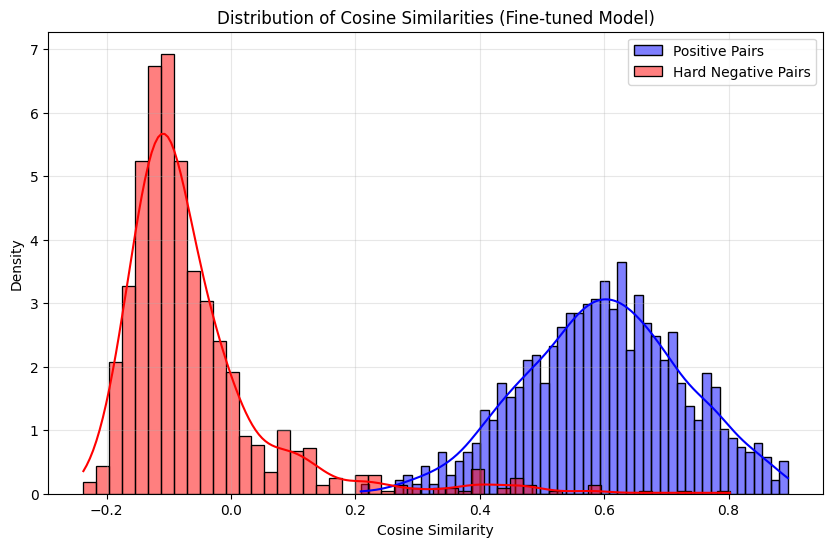

Positives      - Mean: 0.5993, Min: 0.2085, Max: 0.8954
Hard Negatives - Mean: -0.0597, Min: -0.2374, Max: 0.8022
Margin (Mean Pos - Mean HN): 0.6591


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# We will use a sample of 1000 triplets
sample_size = 1000
sample_anchors = anchors_list[:sample_size]
sample_positives = positives_list[:sample_size]
sample_hns = hard_negatives[:sample_size]

print(f"Encoding {sample_size} triplets with the fine-tuned model...")

# Encode using the fine-tuned model ('ft' from Cell 10)
emb_anchors = ft.encode(sample_anchors, batch_size=64, convert_to_numpy=True, normalize_embeddings=True)
emb_pos = ft.encode(sample_positives, batch_size=64, convert_to_numpy=True, normalize_embeddings=True)
emb_hns = ft.encode(sample_hns, batch_size=64, convert_to_numpy=True, normalize_embeddings=True)

# Calculate cosine similarities
sims_pos = (emb_anchors * emb_pos).sum(axis=1)
sims_hn = (emb_anchors * emb_hns).sum(axis=1)

# Plot the distributions
plt.figure(figsize=(10, 6))
sns.histplot(sims_pos, bins=50, color='blue', alpha=0.5, label='Positive Pairs', kde=True, stat='density')
sns.histplot(sims_hn, bins=50, color='red', alpha=0.5, label='Hard Negative Pairs', kde=True, stat='density')

plt.title('Distribution of Cosine Similarities (Fine-tuned Model)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Positives      - Mean: {sims_pos.mean():.4f}, Min: {sims_pos.min():.4f}, Max: {sims_pos.max():.4f}")
print(f"Hard Negatives - Mean: {sims_hn.mean():.4f}, Min: {sims_hn.min():.4f}, Max: {sims_hn.max():.4f}")
print(f"Margin (Mean Pos - Mean HN): {sims_pos.mean() - sims_hn.mean():.4f}")

# Clean up memory
del emb_anchors, emb_pos, emb_hns
import gc, torch
gc.collect()
torch.cuda.empty_cache()